In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE       = "/content/drive/MyDrive/DS340 Final Project/Yelp JSON/yelp_dataset"
REVIEWS    = f"{BASE}/yelp_academic_dataset_review.json"
BUSINESSES = f"{BASE}/yelp_academic_dataset_business.json"
OUTPUT     = "/content/drive/MyDrive/DS340 Final Project/trend_signals.parquet"
CITIES     = {"Philadelphia", "Tampa", "TAMPA", "Nashville"}

Mounted at /content/drive


In [ ]:
!pip install pandas pyarrow

In [ ]:
#Load businesses & filter to your 3 cities
import json
import pandas as pd

businesses = []
with open(BUSINESSES) as f:
    for line in f:
        b = json.loads(line)
        if b.get("city") in CITIES and "Restaurants" in (b.get("categories") or ""):
            businesses.append({"business_id": b["business_id"], "city": b["city"]})

biz_df = pd.DataFrame(businesses)
print(f"Found {len(biz_df)} restaurants across cities")
print(biz_df["city"].value_counts())

Found 11321 restaurants across cities
city
Philadelphia    5852
Tampa           2960
Nashville       2502
TAMPA              7
Name: count, dtype: int64


In [ ]:
# Check how many reviews we're actually capturing
print("Total restaurant records per city:")
print(biz_df["city"].value_counts())

print("\nSample of city names from the raw data:")
import json
cities_found = set()
with open(BUSINESSES) as f:
    for line in f:
        b = json.loads(line)
        cities_found.add(b.get("city", ""))
        if len(cities_found) > 200:
            break

# Look for anything close to your 3 cities
targets = ["philadelphia", "tampa", "nashville"]
for c in sorted(cities_found):
    if any(t in c.lower() for t in targets):
        print(c)

Total restaurant records per city:
city
Philadelphia    5852
Tampa           2960
Nashville       2502
TAMPA              7
Name: count, dtype: int64

Sample of city names from the raw data:
Nashville
Philadelphia
TAMPA
Tampa
Tampa Bay


In [ ]:
#Load reviews & extract food keyword mentions by city/month
FOOD_LEXICON = [
    "birria", "smash burger", "boba", "matcha", "birria tacos",
    "korean fried chicken", "charcuterie", "wagyu", "truffle fries",
    "elote", "tteokbokki", "shakshuka", "cloud eggs", "butter board"
]

valid_ids = set(biz_df["business_id"])
id_to_city = dict(zip(biz_df["business_id"], biz_df["city"]))

records = []
total_counts = []  # track all reviews, not just ones with keyword hits

with open(REVIEWS) as f:
    for line in f:
        r = json.loads(line)
        if r["business_id"] not in valid_ids:
            continue
        text = r["text"].lower()
        date = r["date"][:7]
        city = id_to_city[r["business_id"]]

        total_counts.append({"city": city, "month": date})  # count every review

        for kw in FOOD_LEXICON:
            if kw in text:
                records.append({"city": city, "month": date, "keyword": kw})

mentions_df = pd.DataFrame(records)
total_df = pd.DataFrame(total_counts)
print(f"Total keyword mentions: {len(mentions_df)}")
print(f"Total reviews processed: {len(total_df)}")

Total keyword mentions: 15436
Total reviews processed: 1316706


In [ ]:
# Count mentions per city/month/keyword
counts = mentions_df.groupby(["city", "month", "keyword"]).size().reset_index(name="count")

# Normalize per city+keyword (divide by total reviews that month)
total_reviews = total_df.groupby(["city", "month"]).size().reset_index(name="total")

counts = counts.merge(total_reviews, on=["city", "month"])
counts["trend_score"] = counts["count"] / counts["total"]

# Filter out months with fewer than 50 reviews (unreliable signal)
counts = counts[counts["total"] >= 50]

# Normalize Tampa/TAMPA to one name
counts["city"] = counts["city"].replace("TAMPA", "Tampa")

counts.to_parquet(OUTPUT, index=False)
print("Saved to", OUTPUT)
print(counts.head(10))

Saved to /content/drive/MyDrive/DS340 Final Project/trend_signals.parquet
        city    month               keyword  count  total  trend_score
0  Nashville  2007-10                 elote      1     56     0.017857
1  Nashville  2008-05                matcha      1    233     0.004292
2  Nashville  2008-12                  boba      1    275     0.003636
3  Nashville  2009-04                  boba      1    173     0.005780
4  Nashville  2009-08                 elote      1    232     0.004310
5  Nashville  2010-03  korean fried chicken      1    291     0.003436
6  Nashville  2010-06           charcuterie      1    300     0.003333
7  Nashville  2010-06         truffle fries      1    300     0.003333
8  Nashville  2010-08                  boba      1    466     0.002146
9  Nashville  2010-08         truffle fries      1    466     0.002146


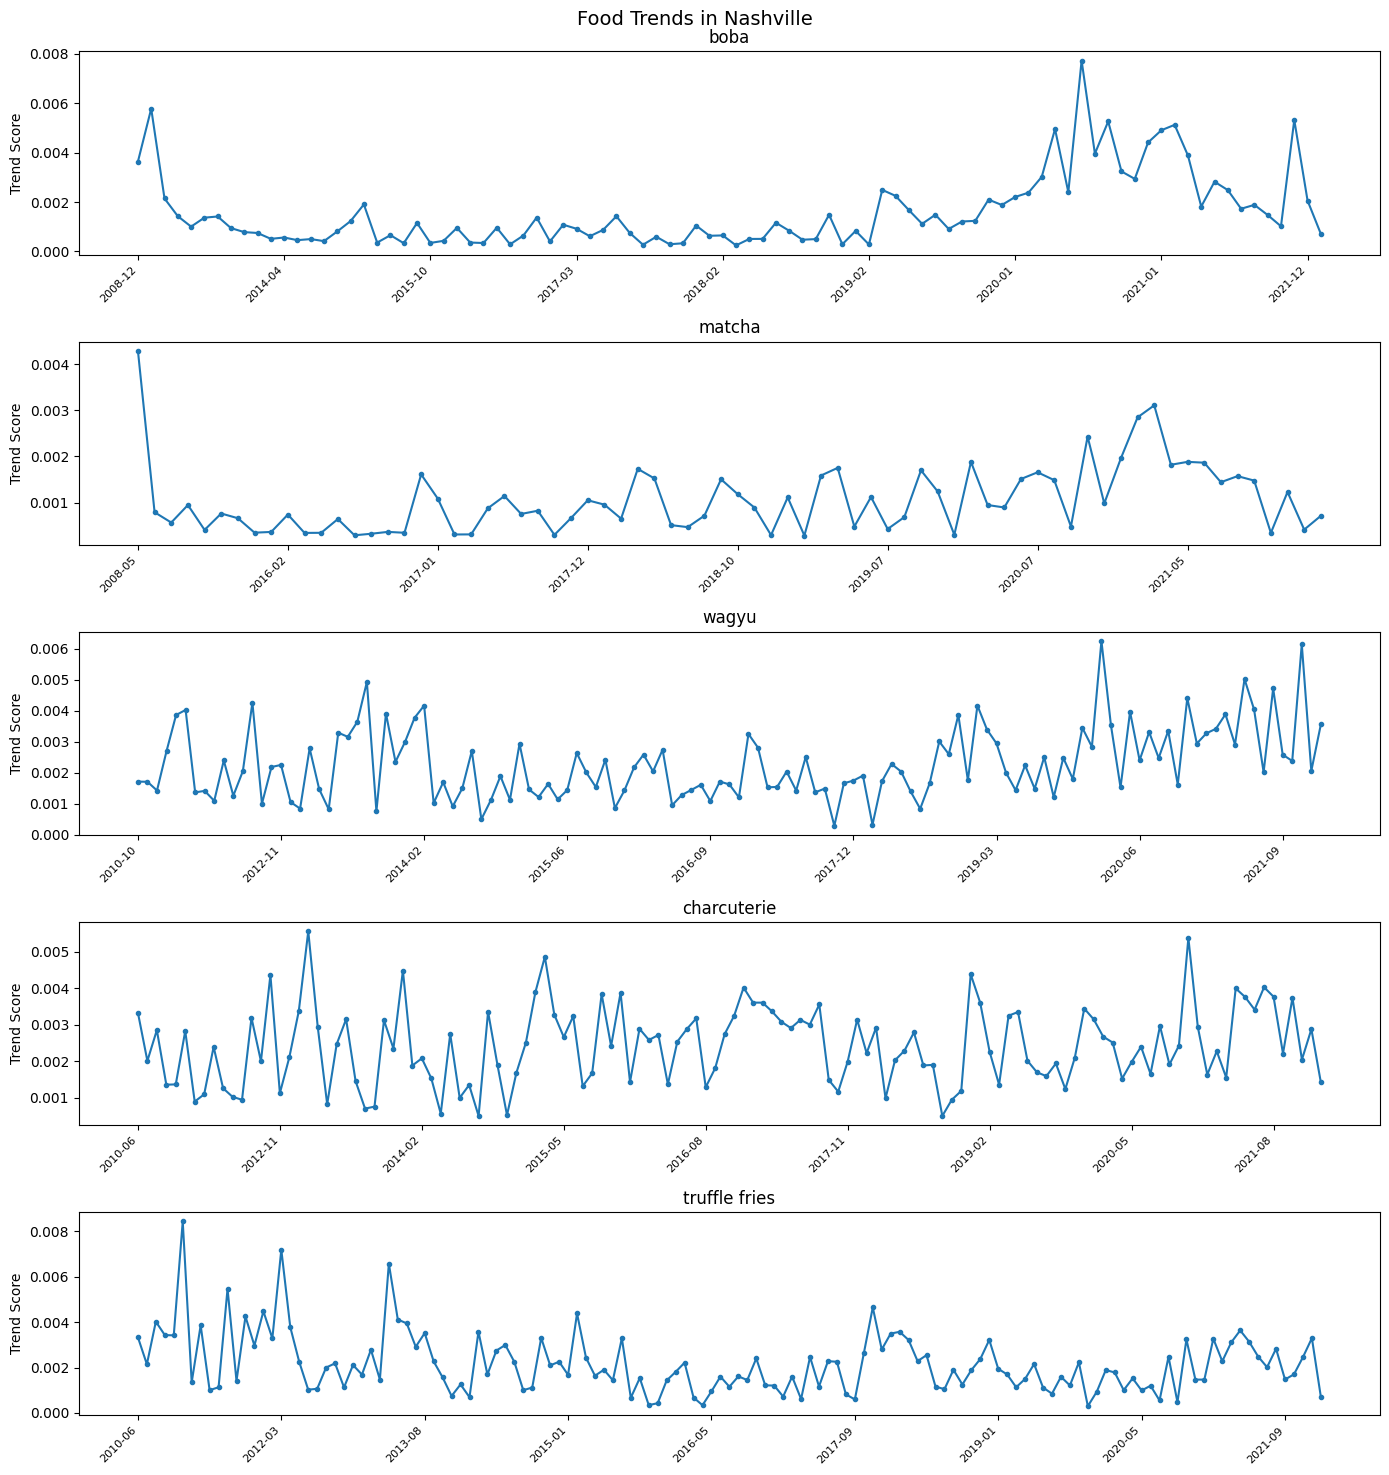

In [ ]:
import matplotlib.pyplot as plt

df = pd.read_parquet(OUTPUT)
keywords_to_plot = ["boba", "matcha", "wagyu", "charcuterie", "truffle fries"]
city = "Nashville"

subset_city = df[df["city"] == city].copy()
fig, axes = plt.subplots(len(keywords_to_plot), 1, figsize=(14, 15), sharex=False)

for ax, kw in zip(axes, keywords_to_plot):
    subset = (
        subset_city[subset_city["keyword"] == kw]
        .sort_values("month")
        .reset_index(drop=True)
    )
    if subset.empty:
        ax.set_title(f"{kw} (no data)")
        continue
    ax.plot(range(len(subset)), subset["trend_score"], marker="o", markersize=3)
    ax.set_title(kw)
    ax.set_ylabel("Trend Score")
    n = len(subset)
    step = max(n // 8, 1)
    tick_positions = list(range(0, n, step))
    tick_labels = [subset["month"].iloc[i] for i in tick_positions]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=8)

plt.suptitle(f"Food Trends in {city}", fontsize=14)
plt.tight_layout()
plt.show()

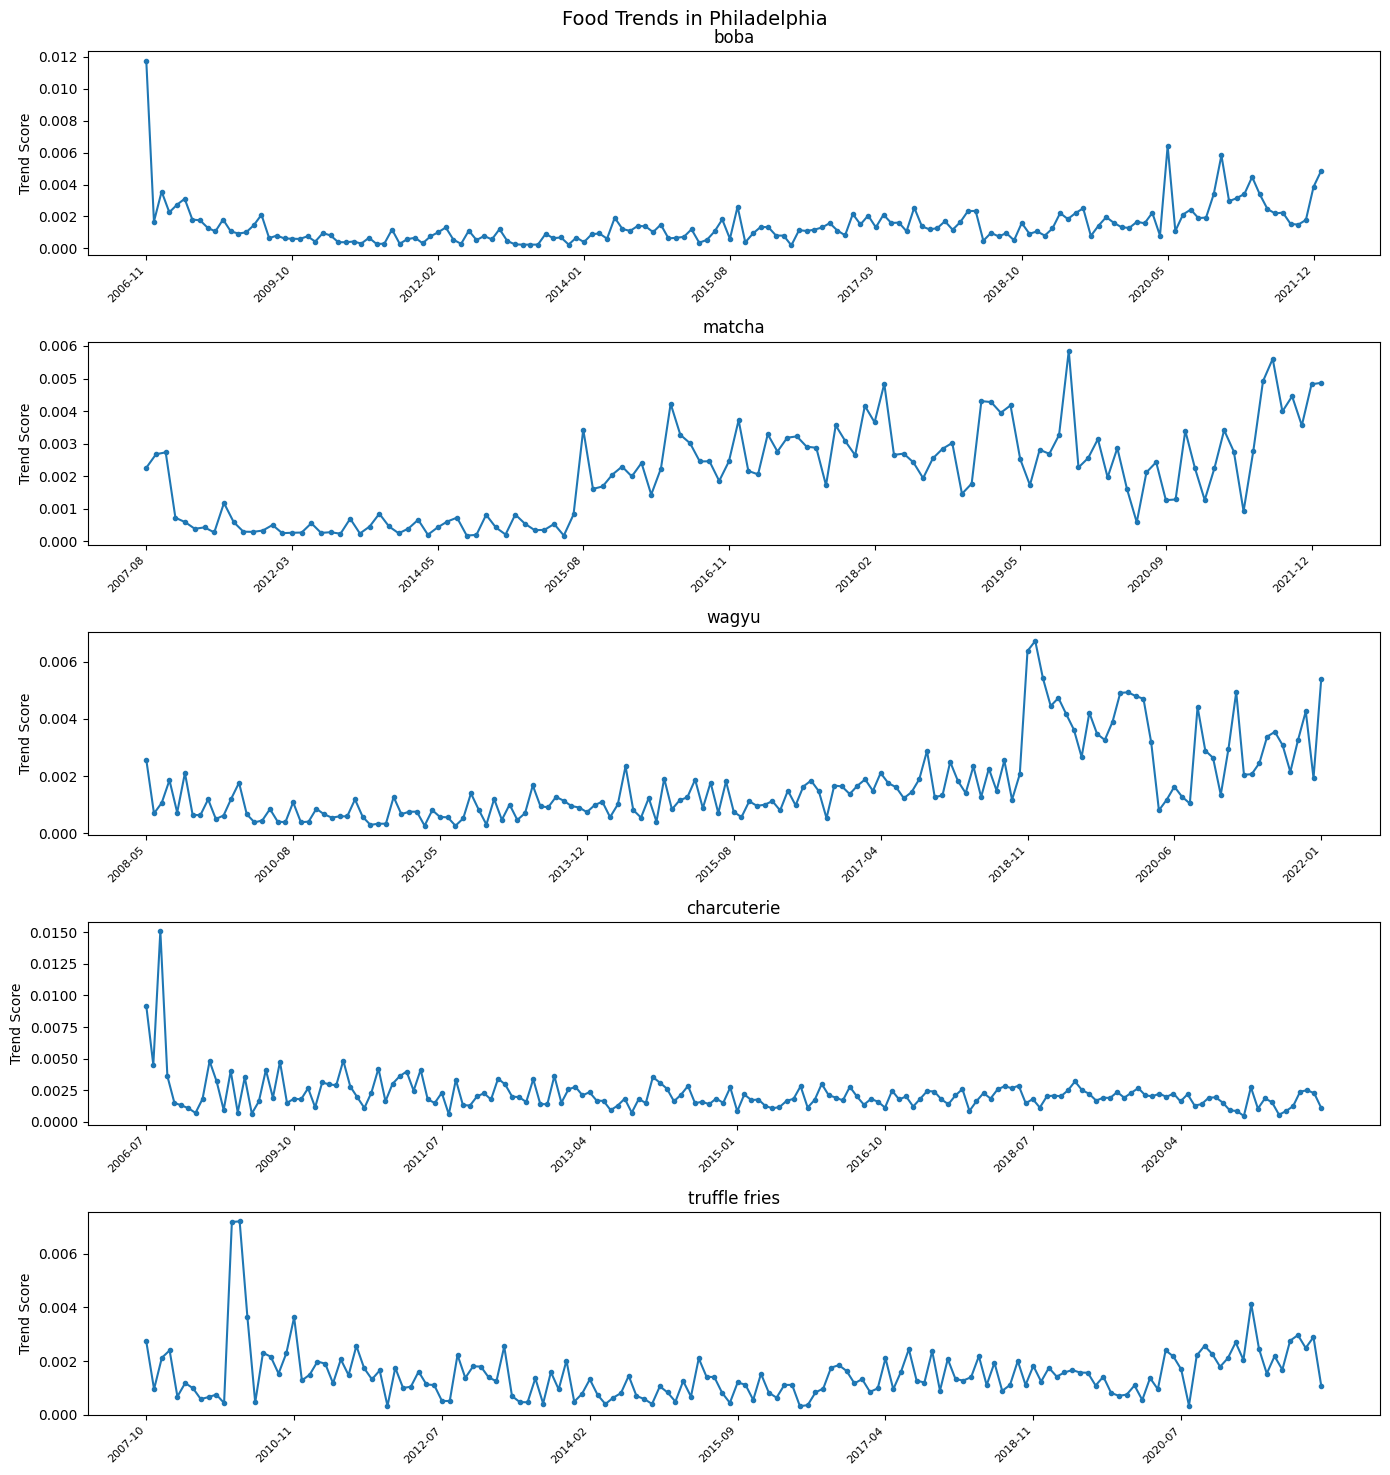

In [ ]:
city = "Philadelphia"

subset_city = df[df["city"] == city].copy()
fig, axes = plt.subplots(len(keywords_to_plot), 1, figsize=(14, 15), sharex=False)

for ax, kw in zip(axes, keywords_to_plot):
    subset = (
        subset_city[subset_city["keyword"] == kw]
        .sort_values("month")
        .reset_index(drop=True)
    )
    if subset.empty:
        ax.set_title(f"{kw} (no data)")
        continue
    ax.plot(range(len(subset)), subset["trend_score"], marker="o", markersize=3)
    ax.set_title(kw)
    ax.set_ylabel("Trend Score")
    n = len(subset)
    step = max(n // 8, 1)
    tick_positions = list(range(0, n, step))
    tick_labels = [subset["month"].iloc[i] for i in tick_positions]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=8)

plt.suptitle(f"Food Trends in {city}", fontsize=14)
plt.tight_layout()
plt.show()

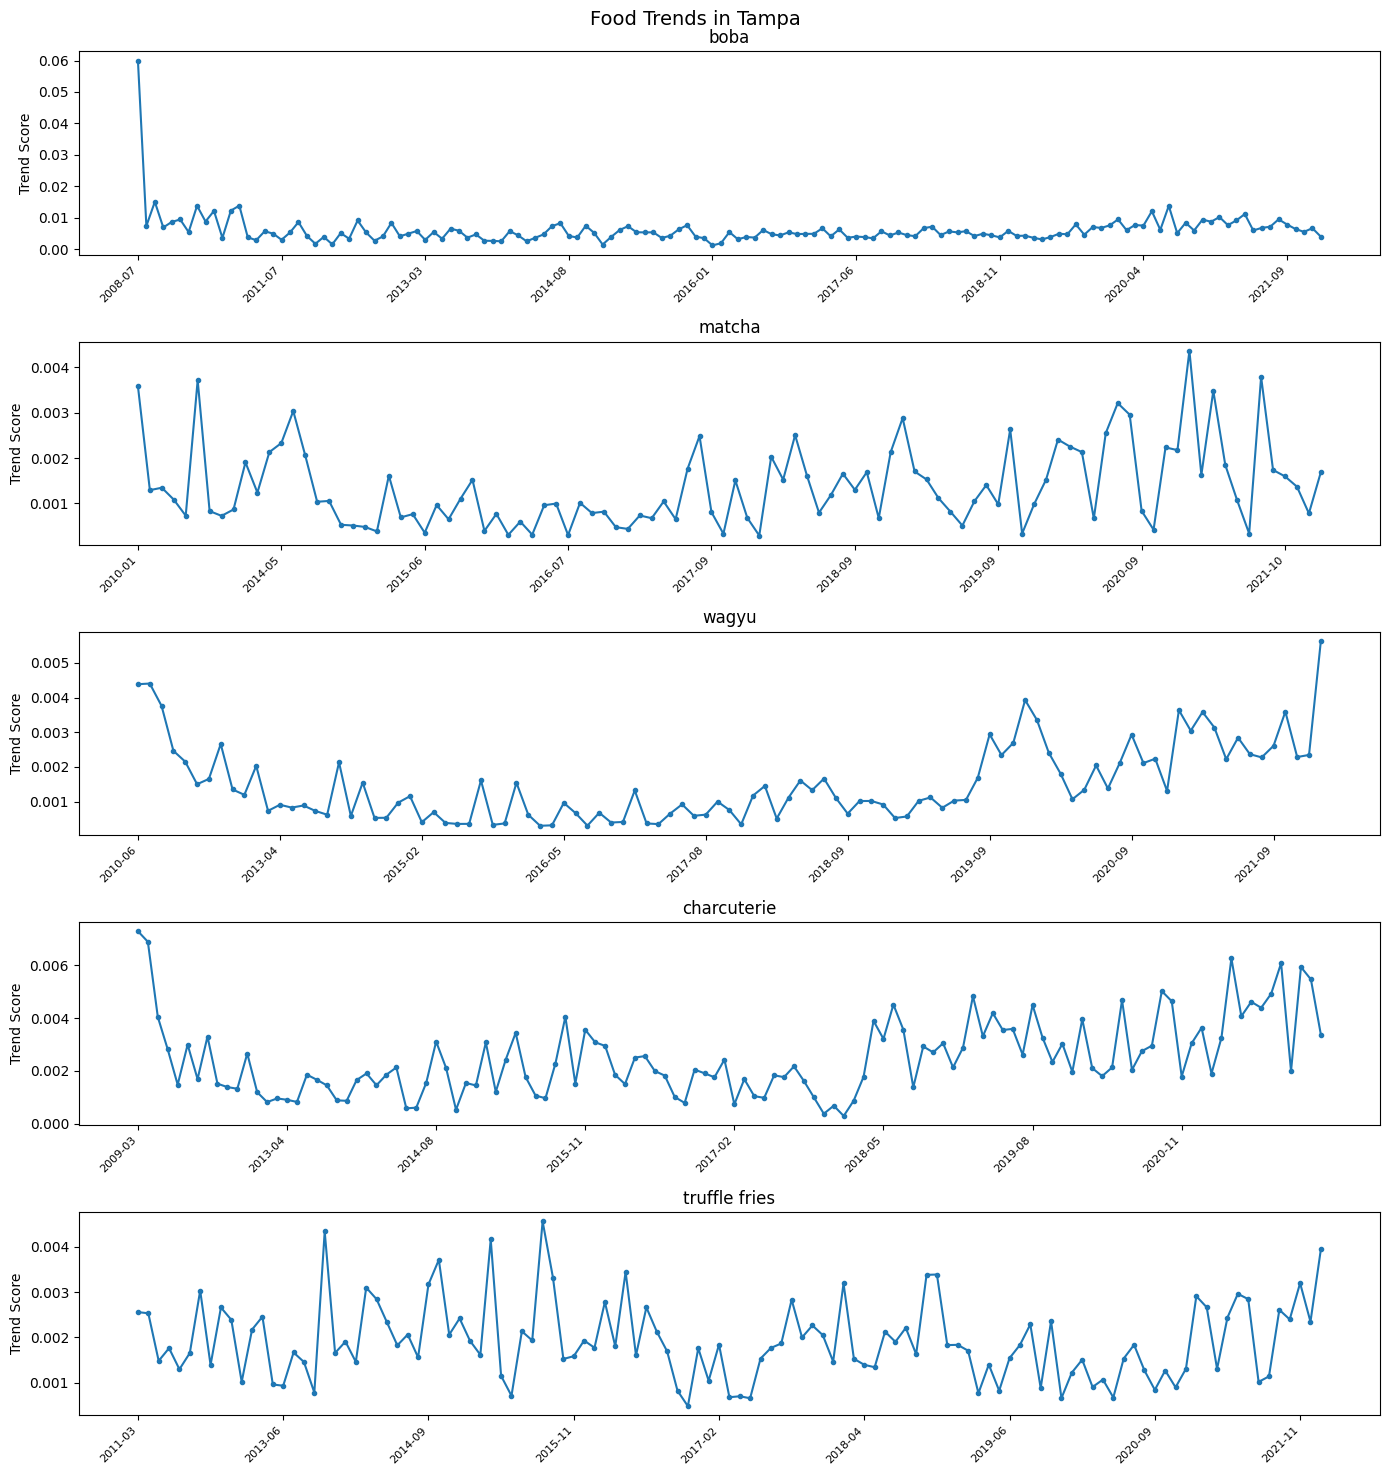

In [ ]:
city = "Tampa"

subset_city = df[df["city"].isin(["Tampa", "TAMPA"])].copy()
subset_city["city"] = "Tampa"
fig, axes = plt.subplots(len(keywords_to_plot), 1, figsize=(14, 15), sharex=False)

for ax, kw in zip(axes, keywords_to_plot):
    subset = (
        subset_city[subset_city["keyword"] == kw]
        .sort_values("month")
        .reset_index(drop=True)
    )
    if subset.empty:
        ax.set_title(f"{kw} (no data)")
        continue
    ax.plot(range(len(subset)), subset["trend_score"], marker="o", markersize=3)
    ax.set_title(kw)
    ax.set_ylabel("Trend Score")
    n = len(subset)
    step = max(n // 8, 1)
    tick_positions = list(range(0, n, step))
    tick_labels = [subset["month"].iloc[i] for i in tick_positions]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=8)

plt.suptitle(f"Food Trends in {city}", fontsize=14)
plt.tight_layout()
plt.show()

##Add smoothing and train/test/split

In [ ]:
import pandas as pd
from itertools import product

OUTPUT_FILLED = OUTPUT.replace(".parquet", "_filled.parquet")

df = pd.read_parquet(OUTPUT)

# Normalize Tampa/TAMPA
df["city"] = df["city"].replace("TAMPA", "Tampa")

all_months   = sorted(df["month"].unique())
all_keywords = df["keyword"].unique()
all_cities   = df["city"].unique()

# Build complete index and merge
full_index = pd.DataFrame(
    list(product(all_cities, all_months, all_keywords)),
    columns=["city", "month", "keyword"]
)

df_filled = full_index.merge(df[["city", "month", "keyword", "trend_score"]],
                              on=["city", "month", "keyword"], how="left")
df_filled["trend_score"] = df_filled["trend_score"].fillna(0)

df_filled = df_filled.sort_values(["city", "keyword", "month"])

# Rolling 3-month average smoothing per city+keyword
df_filled["trend_score_smooth"] = (
    df_filled
    .groupby(["city", "keyword"])["trend_score"]
    .transform(lambda s: s.rolling(window=3, min_periods=1, center=False).mean())
)

# Keep a separate centered version for visualization only
df_filled["trend_score_smooth_viz"] = (
    df_filled
    .groupby(["city", "keyword"])["trend_score"]
    .transform(lambda s: s.rolling(window=3, min_periods=1, center=True).mean())
)

df_filled.to_parquet(OUTPUT_FILLED, index=False)
print("Saved gap-filled + smoothed data to", OUTPUT_FILLED)
print(df_filled.shape)
print(df_filled.head(10))

Saved gap-filled + smoothed data to /content/drive/MyDrive/DS340 Final Project/trend_signals_filled.parquet
(6444, 6)
          city    month keyword  trend_score  trend_score_smooth  \
6    Nashville  2006-07  birria          0.0                 0.0   
18   Nashville  2006-11  birria          0.0                 0.0   
30   Nashville  2007-02  birria          0.0                 0.0   
42   Nashville  2007-04  birria          0.0                 0.0   
54   Nashville  2007-06  birria          0.0                 0.0   
66   Nashville  2007-08  birria          0.0                 0.0   
78   Nashville  2007-09  birria          0.0                 0.0   
90   Nashville  2007-10  birria          0.0                 0.0   
102  Nashville  2007-11  birria          0.0                 0.0   
114  Nashville  2007-12  birria          0.0                 0.0   

     trend_score_smooth_viz  
6                       0.0  
18                      0.0  
30                      0.0  
42           

In [ ]:
# train test split
OUTPUT_FILLED = OUTPUT.replace(".parquet", "_filled.parquet")
df_filled = pd.read_parquet(OUTPUT_FILLED)

all_months = sorted(df_filled["month"].unique())
print(f"Data spans: {all_months[0]}  →  {all_months[-1]}  ({len(all_months)} months)")

TRAIN_END = "2018-12"
VAL_END   = "2019-06"

df_train = df_filled[df_filled["month"] <= TRAIN_END].copy()
df_val   = df_filled[(df_filled["month"] > TRAIN_END) & (df_filled["month"] <= VAL_END)].copy()
df_test  = df_filled[df_filled["month"] > VAL_END].copy()

print(f"\nTrain: {df_train['month'].min()} → {df_train['month'].max()}  ({df_train['month'].nunique()} months, {len(df_train)} rows)")
print(f"Val:   {df_val['month'].min()} → {df_val['month'].max()}  ({df_val['month'].nunique()} months, {len(df_val)} rows)")
print(f"Test:  {df_test['month'].min()} → {df_test['month'].max()}  ({df_test['month'].nunique()} months, {len(df_test)} rows)")
print(f"\nCities — Train: {sorted(df_train['city'].unique())}")
print(f"Cities — Val:   {sorted(df_val['city'].unique())}")
print(f"Cities — Test:  {sorted(df_test['city'].unique())}")

assert set(df_train["month"]).isdisjoint(set(df_test["month"])), "Month overlap between train and test!"
print("\nNo month overlap confirmed.")

SPLIT_DIR = OUTPUT.replace("trend_signals.parquet", "")
df_train.to_parquet(SPLIT_DIR + "split_train.parquet", index=False)
df_val.to_parquet(SPLIT_DIR + "split_val.parquet", index=False)
df_test.to_parquet(SPLIT_DIR + "split_test.parquet", index=False)
print("Splits saved.")

Data spans: 2006-07  →  2022-01  (179 months)

Train: 2006-07 → 2018-12  (142 months, 5112 rows)
Val:   2019-01 → 2019-06  (6 months, 216 rows)
Test:  2019-07 → 2022-01  (31 months, 1116 rows)

Cities — Train: ['Nashville', 'Philadelphia', 'Tampa']
Cities — Val:   ['Nashville', 'Philadelphia', 'Tampa']
Cities — Test:  ['Nashville', 'Philadelphia', 'Tampa']

No month overlap confirmed.
Splits saved.


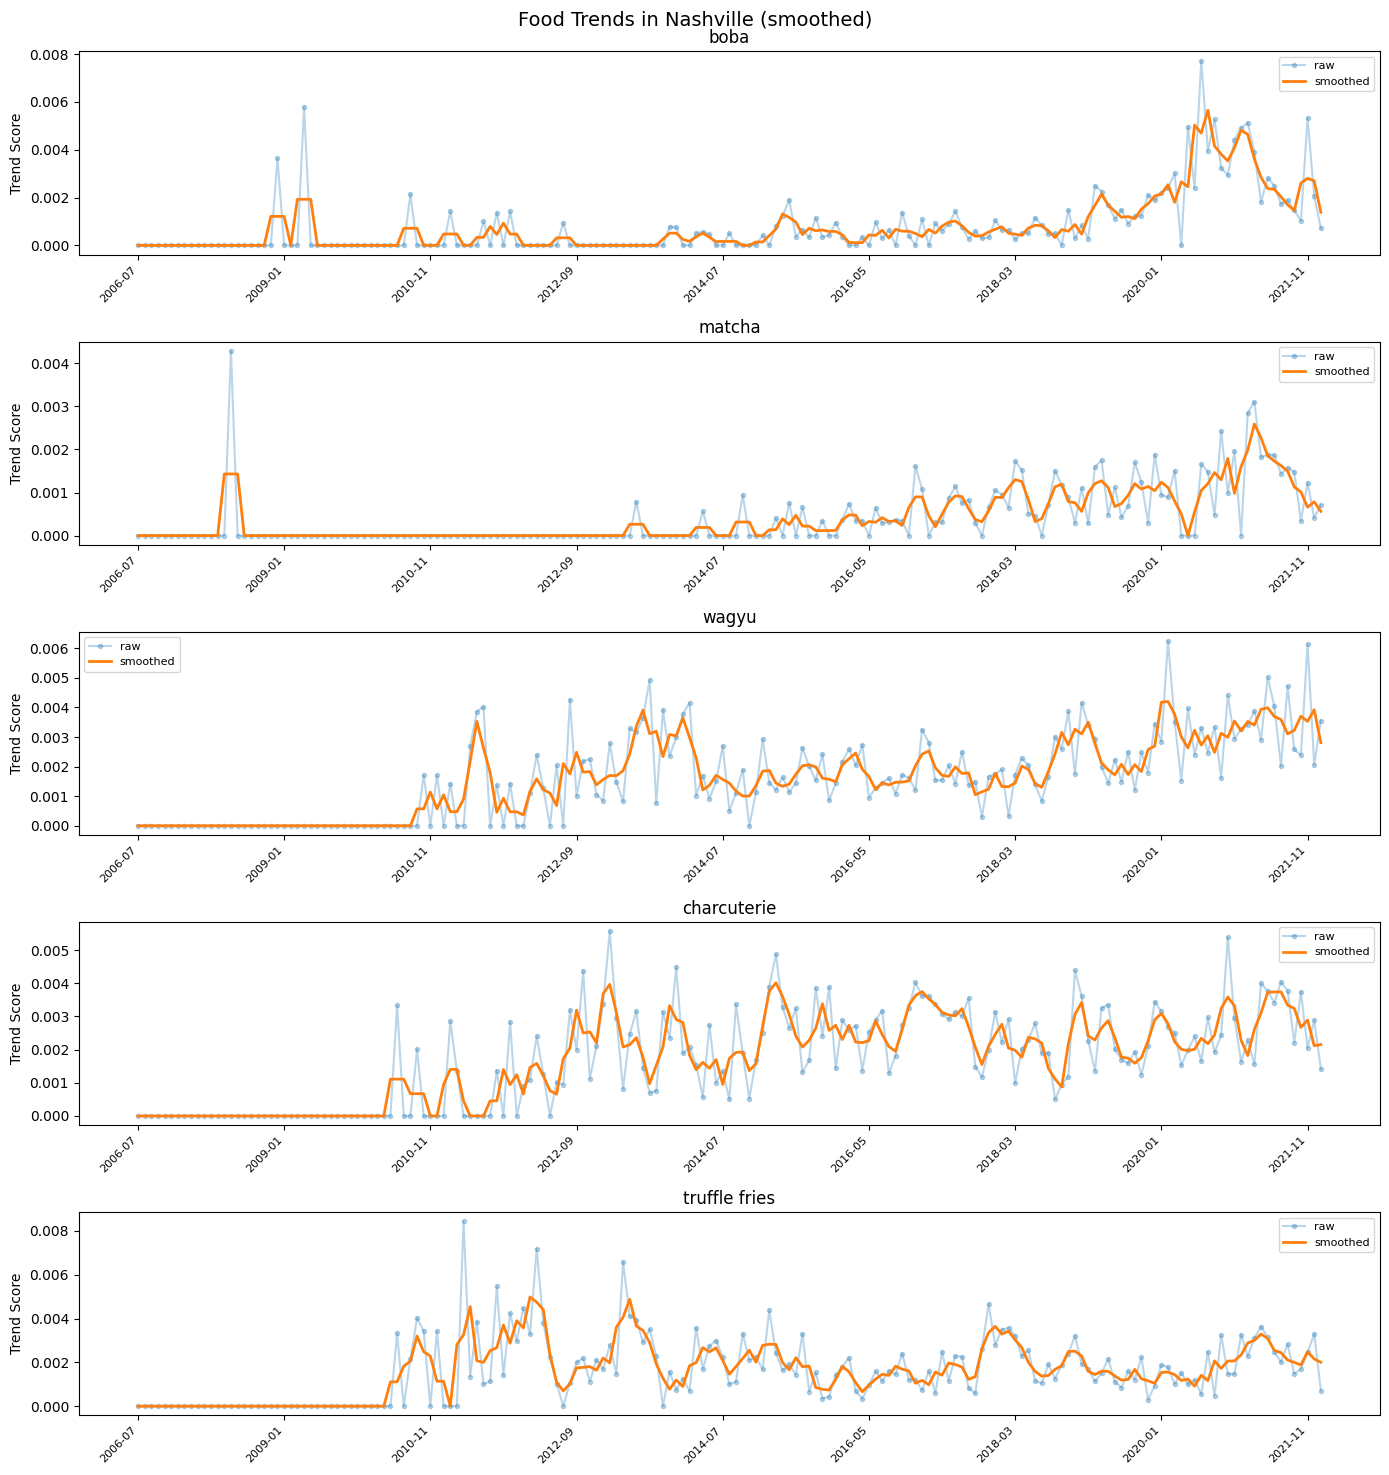

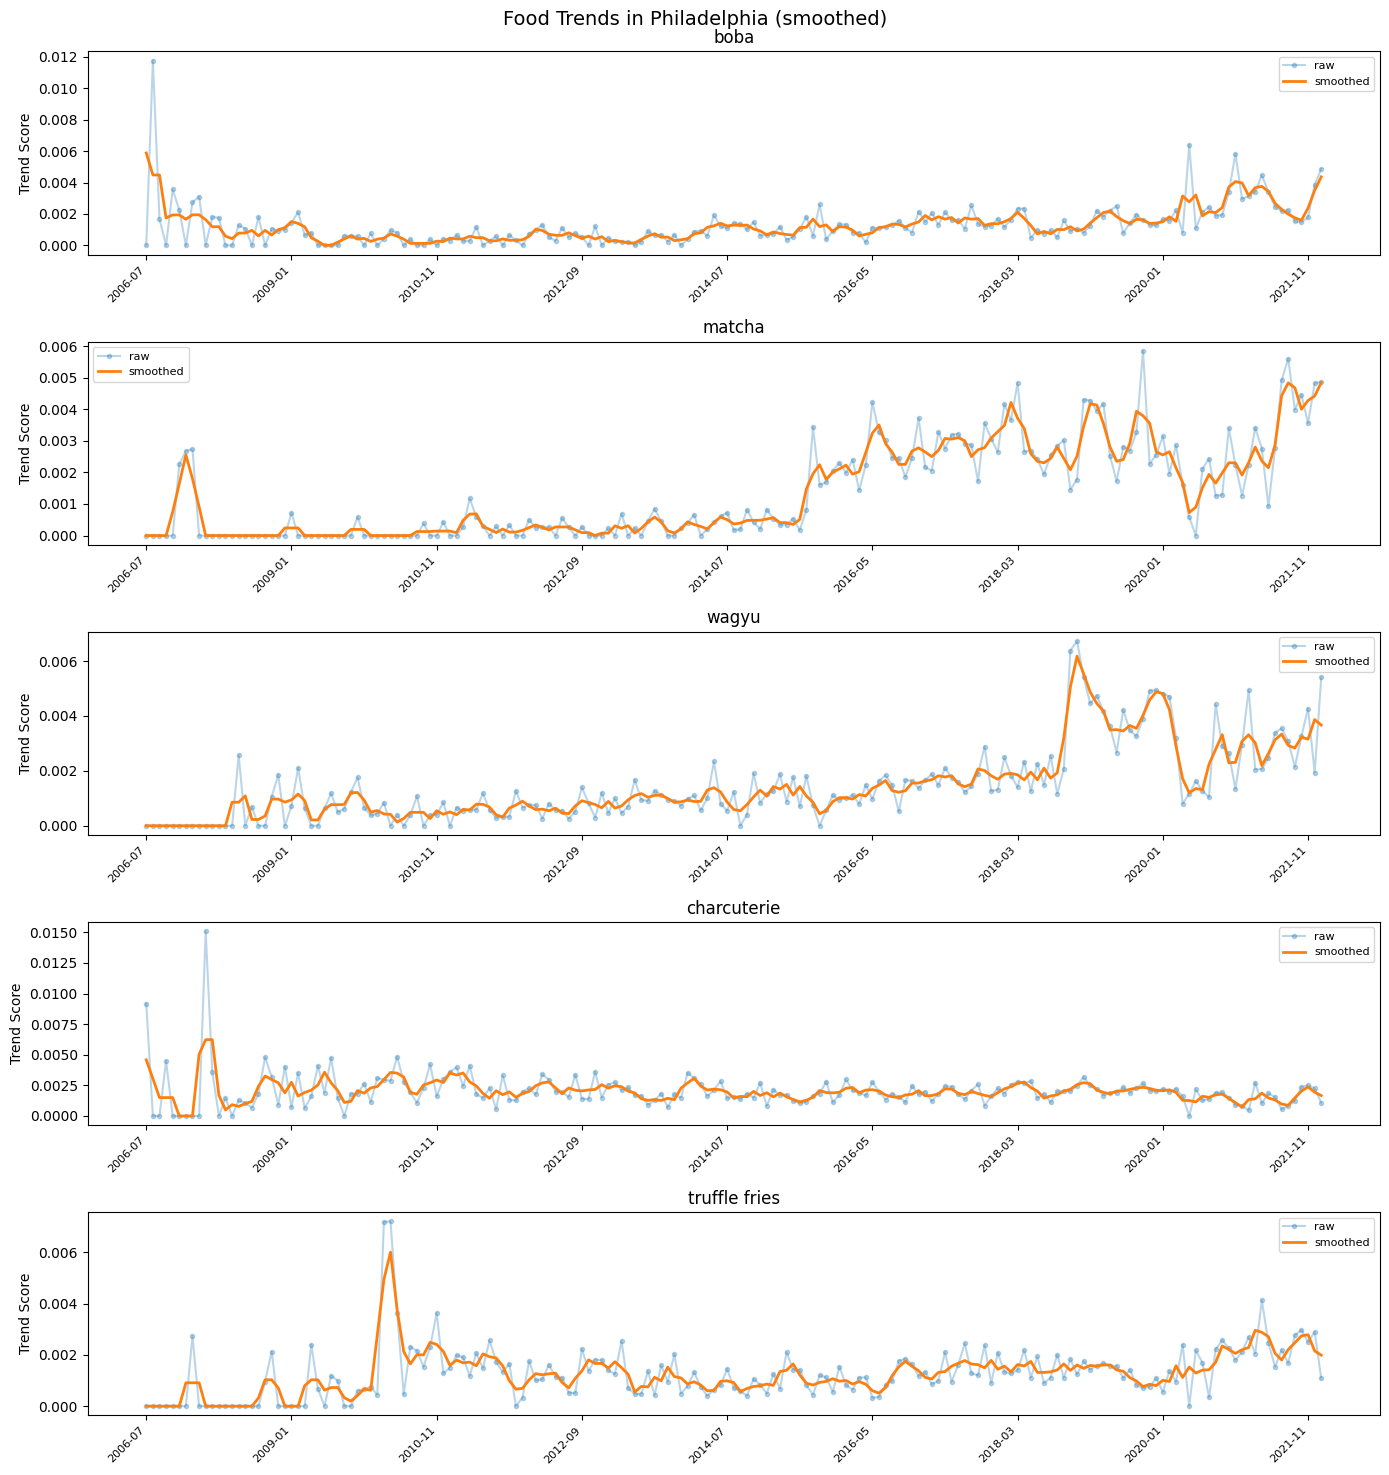

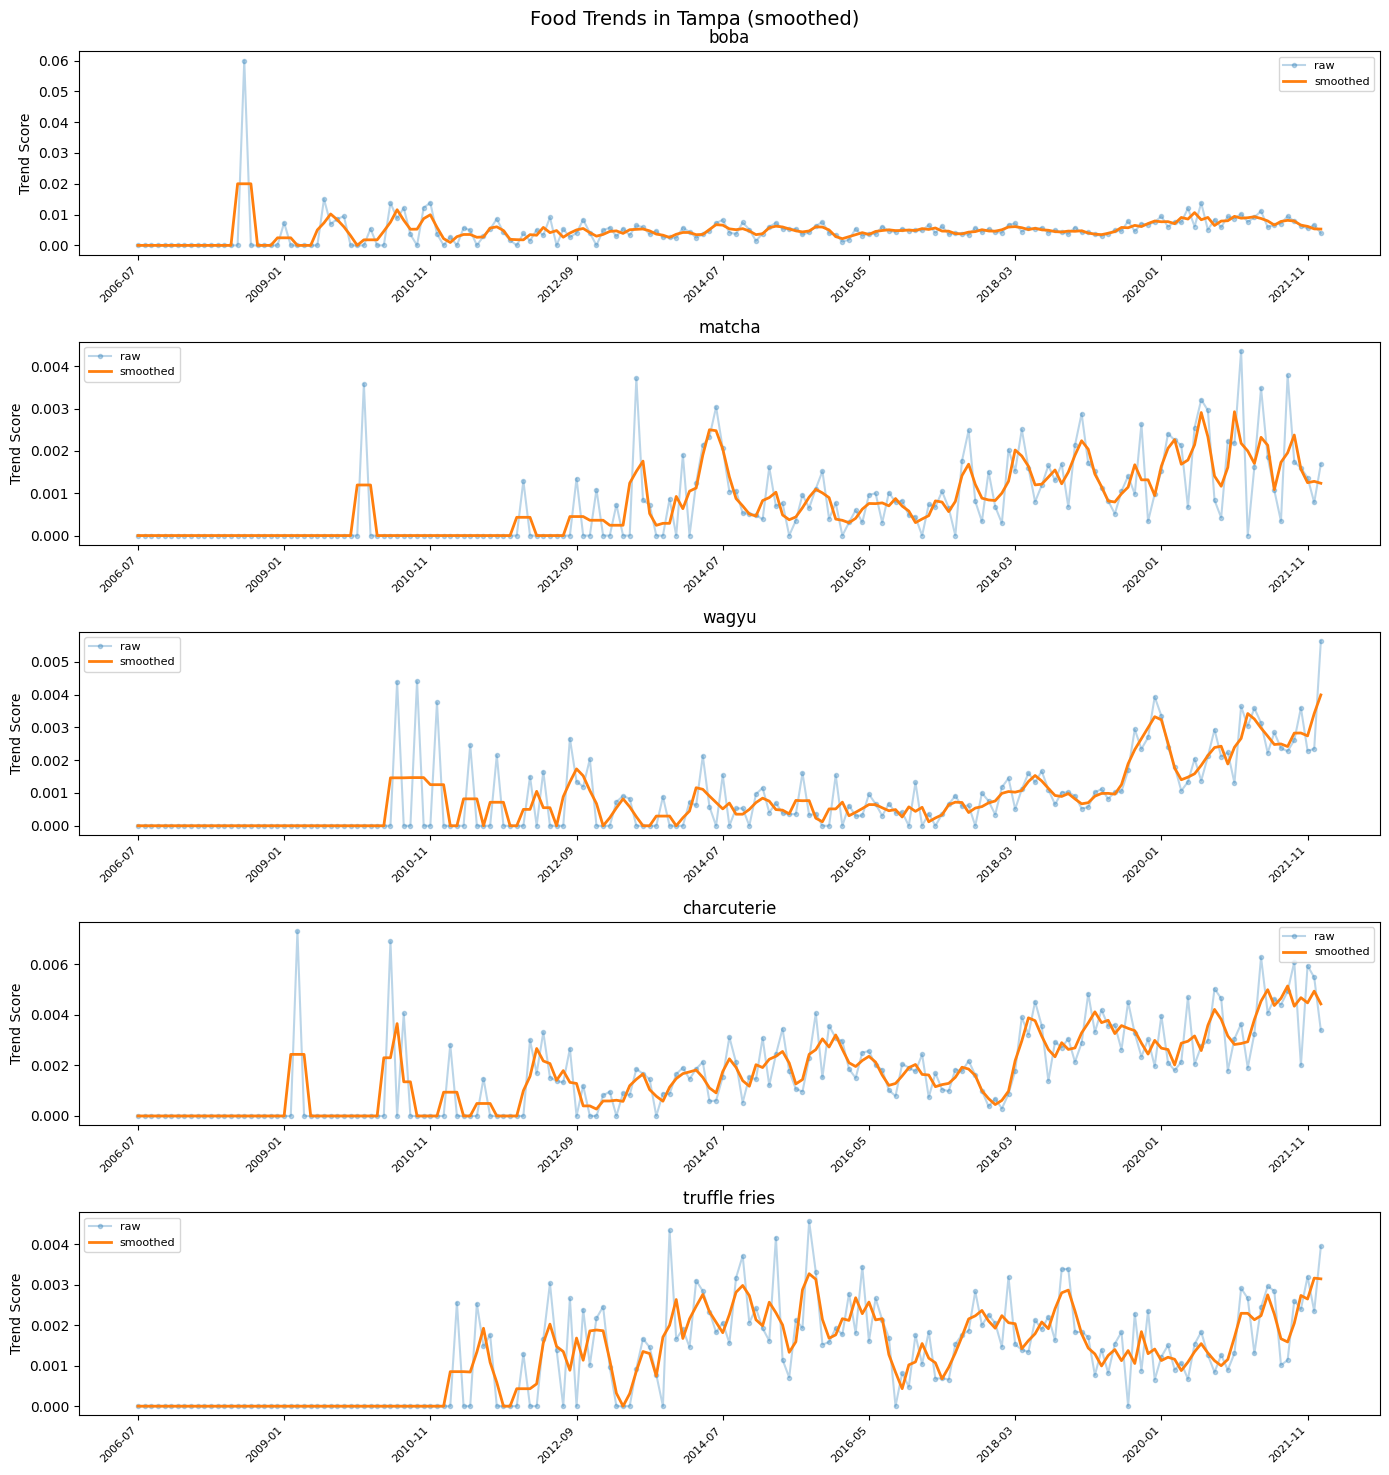

In [ ]:
import matplotlib.pyplot as plt

OUTPUT_FILLED = OUTPUT.replace(".parquet", "_filled.parquet")
df_filled = pd.read_parquet(OUTPUT_FILLED)
keywords_to_plot = ["boba", "matcha", "wagyu", "charcuterie", "truffle fries"]

for city in ["Nashville", "Philadelphia", "Tampa"]:
    fig, axes = plt.subplots(len(keywords_to_plot), 1, figsize=(14, 15), sharex=False)
    for ax, kw in zip(axes, keywords_to_plot):
        subset = df_filled[
            (df_filled["city"] == city) & (df_filled["keyword"] == kw)
        ].sort_values("month").reset_index(drop=True)

        ax.plot(range(len(subset)), subset["trend_score"], alpha=0.3,
                marker="o", markersize=3, label="raw")
        ax.plot(range(len(subset)), subset["trend_score_smooth_viz"],
                linewidth=2, label="smoothed")
        ax.set_title(kw)
        ax.set_ylabel("Trend Score")
        ax.legend(fontsize=8)

        # Fix crowded x-axis: show only ~8 evenly spaced labels
        n = len(subset)
        step = max(n // 8, 1)
        tick_positions = list(range(0, n, step))
        tick_labels = [subset["month"].iloc[i] for i in tick_positions]
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=8)

    plt.suptitle(f"Food Trends in {city} (smoothed)", fontsize=14)
    plt.tight_layout()
    plt.show()